# Buzzhive CNN Classifier

This notebook implements and trains a Convolutional Neural Network for beehive audio classification:
1. CNN architecture design
2. Training loop with early stopping
3. Model evaluation and visualization
4. Model saving and export


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import librosa

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Paths
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = OUTPUT_DIR / 'processed'
MODEL_DIR = OUTPUT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load configuration
with open(PROCESSED_DIR / 'config.json', 'r') as f:
    config_dict = json.load(f)
print("Configuration loaded:", config_dict)


Using device: mps
Configuration loaded: {'sample_rate': 22050, 'duration': 10.0, 'n_mels': 128, 'n_fft': 2048, 'hop_length': 512, 'fmin': 20, 'fmax': 8000, 'n_mfcc': 13, 'pre_emphasis': 0.97, 'class_names': {'0': 'Queenright', '1': 'Queenless', '2': 'Queen_New', '3': 'Queen_Accepted'}, 'num_classes': 4}


## 1. Load Data and Create DataLoaders


In [2]:
# Audio configuration class
class AudioConfig:
    SAMPLE_RATE = config_dict['sample_rate']
    DURATION = config_dict['duration']
    N_MELS = config_dict['n_mels']
    N_FFT = config_dict['n_fft']
    HOP_LENGTH = config_dict['hop_length']
    FMIN = config_dict['fmin']
    FMAX = config_dict['fmax']
    N_MFCC = config_dict['n_mfcc']
    PRE_EMPHASIS = config_dict['pre_emphasis']
    
    @property
    def n_samples(self):
        return int(self.SAMPLE_RATE * self.DURATION)

config = AudioConfig()
CLASS_NAMES = {int(k): v for k, v in config_dict['class_names'].items()}
NUM_CLASSES = config_dict['num_classes']

print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")


Number of classes: 4
Class names: {0: 'Queenright', 1: 'Queenless', 2: 'Queen_New', 3: 'Queen_Accepted'}


In [3]:
# Audio preprocessing functions (from notebook 2)
def load_audio(file_path, target_sr=22050, duration=None):
    y, sr = librosa.load(file_path, sr=target_sr, duration=duration, mono=True)
    return y, sr

def apply_pre_emphasis(y, coef=0.97):
    return np.append(y[0], y[1:] - coef * y[:-1])

def normalize_audio(y):
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val
    return y

def pad_or_truncate(y, target_length):
    if len(y) > target_length:
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]
    elif len(y) < target_length:
        pad_left = (target_length - len(y)) // 2
        pad_right = target_length - len(y) - pad_left
        y = np.pad(y, (pad_left, pad_right), mode='constant')
    return y

def preprocess_audio(file_path, config):
    y, sr = load_audio(file_path, target_sr=config.SAMPLE_RATE)
    y = apply_pre_emphasis(y, config.PRE_EMPHASIS)
    y = normalize_audio(y)
    y = pad_or_truncate(y, config.n_samples)
    return y

def extract_melspectrogram(y, config, to_db=True):
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=config.SAMPLE_RATE, n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH, n_mels=config.N_MELS,
        fmin=config.FMIN, fmax=config.FMAX
    )
    if to_db:
        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec


In [4]:
# SpecAugment
class SpecAugment:
    def __init__(self, freq_mask_param=15, time_mask_param=35, n_freq_masks=2, n_time_masks=2):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
    
    def __call__(self, spec):
        spec = spec.copy()
        n_mels, n_time = spec.shape
        
        for _ in range(self.n_freq_masks):
            f = np.random.randint(0, self.freq_mask_param)
            f0 = np.random.randint(0, max(1, n_mels - f))
            spec[f0:f0 + f, :] = 0
        
        for _ in range(self.n_time_masks):
            t = np.random.randint(0, min(self.time_mask_param, n_time))
            t0 = np.random.randint(0, max(1, n_time - t))
            spec[:, t0:t0 + t] = 0
        
        return spec


# Dataset class
class BeehiveDataset(Dataset):
    def __init__(self, df, config, augment=False):
        self.df = df.reset_index(drop=True)
        self.config = config
        self.augment = augment
        self.spec_augment = SpecAugment() if augment else None
        
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.df['queen_status'].values)
        self.num_classes = len(self.label_encoder.classes_)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = row['audio_path']
        label = self.labels[idx]
        
        y = preprocess_audio(audio_path, self.config)
        mel_spec = extract_melspectrogram(y, self.config)
        
        if self.augment and self.spec_augment:
            mel_spec = self.spec_augment(mel_spec)
        
        mel_spec = torch.FloatTensor(mel_spec).unsqueeze(0)
        label = torch.LongTensor([label]).squeeze()
        
        return mel_spec, label
    
    def get_class_weights(self):
        class_counts = np.bincount(self.labels)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * len(class_counts)
        return torch.FloatTensor(weights)


In [5]:
# Load data splits
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Create datasets
train_dataset = BeehiveDataset(train_df, config, augment=True)
val_dataset = BeehiveDataset(val_df, config, augment=False)
test_dataset = BeehiveDataset(test_df, config, augment=False)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Get sample batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nBatch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")


Train samples: 4967
Validation samples: 711
Test samples: 1422

Batch shape: torch.Size([32, 1, 128, 431])
Labels shape: torch.Size([32])


## 2. CNN Model Architecture


In [6]:
class BeehiveCNN(nn.Module):
    """
    CNN for beehive audio classification using mel-spectrograms.
    Architecture: 3 Conv blocks + Global Average Pooling + Dense layers
    """
    
    def __init__(self, num_classes=4, dropout=0.3):
        super(BeehiveCNN, self).__init__()
        
        # Convolutional blocks
        # Input: (batch, 1, 128, ~431) - (batch, channels, n_mels, time)
        
        # Block 1: 32 filters
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout)
        )
        
        # Block 2: 64 filters
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout)
        )
        
        # Block 3: 128 filters
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout)
        )
        
        # Block 4: 256 filters
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x
    
    def get_features(self, x):
        """Extract features before final classification layer."""
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        return x


# Create model
model = BeehiveCNN(num_classes=NUM_CLASSES, dropout=0.3).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


BeehiveCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=Fa

In [7]:
# Test forward pass
with torch.no_grad():
    test_input = sample_batch.to(device)
    test_output = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")


Input shape: torch.Size([32, 1, 128, 431])
Output shape: torch.Size([32, 4])


## 3. Training Configuration


In [ ]:
# Training hyperparameters
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100
PATIENCE = 10  # Early stopping patience

# Loss function with class weights
class_weights = train_dataset.get_class_weights().to(device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


Class weights: tensor([1.3083, 1.4369, 0.8738, 0.3810], device='mps:0')


## 4. Training Loop


In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_idx, (data, target) in enumerate(tqdm(loader, desc="Training", leave=False)):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = output.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, target in tqdm(loader, desc="Validating", leave=False):
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item()
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1, all_preds, all_labels


In [10]:
# Training loop with early stopping
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0
patience_counter = 0
best_model_state = None

print("Starting training...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, val_preds, val_labels = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_f1)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    # Print progress
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! F1: {best_val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("=" * 60)
print(f"Training complete. Best validation F1: {best_val_f1:.4f}")


Starting training...


Epoch   1/100 | Train Loss: 1.3919, Acc: 0.3044, F1: 0.3236 | Val Loss: 1.3751, Acc: 0.5401, F1: 0.4307
  -> New best model! F1: 0.4307


Epoch   2/100 | Train Loss: 1.3776, Acc: 0.3930, F1: 0.3939 | Val Loss: 1.3450, Acc: 0.3277, F1: 0.3422


Epoch   3/100 | Train Loss: 1.3375, Acc: 0.4838, F1: 0.4670 | Val Loss: 1.3093, Acc: 0.5907, F1: 0.4955
  -> New best model! F1: 0.4955


Epoch   4/100 | Train Loss: 1.3222, Acc: 0.5259, F1: 0.4743 | Val Loss: 1.3096, Acc: 0.5823, F1: 0.5082
  -> New best model! F1: 0.5082


...

Epoch  36/100 | Train Loss: 1.2207, Acc: 0.5671, F1: 0.5451 | Val Loss: 1.1743, Acc: 0.6301, F1: 0.6004


Epoch  37/100 | Train Loss: 1.2099, Acc: 0.5786, F1: 0.5560 | Val Loss: 1.1619, Acc: 0.6273, F1: 0.6011


Epoch  38/100 | Train Loss: 1.2033, Acc: 0.5808, F1: 0.5591 | Val Loss: 1.1566, Acc: 0.6231, F1: 0.5907


Epoch  39/100 | Train Loss: 1.1994, Acc: 0.5766, F1: 0.5550 | Val Loss: 1.1523, Acc: 0.6273, F1: 0.5993


Epoch  40/100 | Train Loss: 1.2119, Acc: 0.5798, F1: 0.5593 | Val Loss: 1.1574, Acc: 0.6146, F1: 0.5773

Early stopping at epoch 40
Training complete. Best validation F1: 0.6038


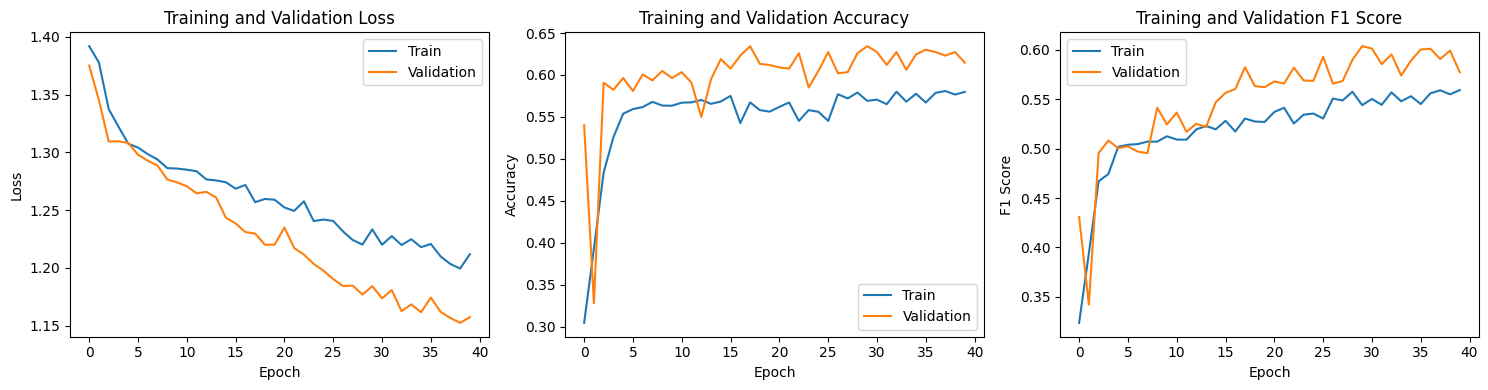

In [11]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()

# F1 Score
axes[2].plot(history['train_f1'], label='Train')
axes[2].plot(history['val_f1'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Training and Validation F1 Score')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Evaluation


In [12]:
# Load best model
model.load_state_dict(best_model_state)

# Evaluate on test set
test_loss, test_acc, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, device)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


TEST SET EVALUATION
Test Loss: 1.1589
Test Accuracy: 0.6118
Test F1 Score: 0.5819


In [13]:
# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))



Classification Report:
                precision    recall  f1-score   support

    Queenright       0.46      0.40      0.43       209
     Queenless       0.40      0.35      0.37       190
     Queen_New       0.61      0.27      0.38       310
Queen_Accepted       0.68      0.89      0.77       713

      accuracy                           0.61      1422
     macro avg       0.54      0.48      0.49      1422
  weighted avg       0.59      0.61      0.58      1422



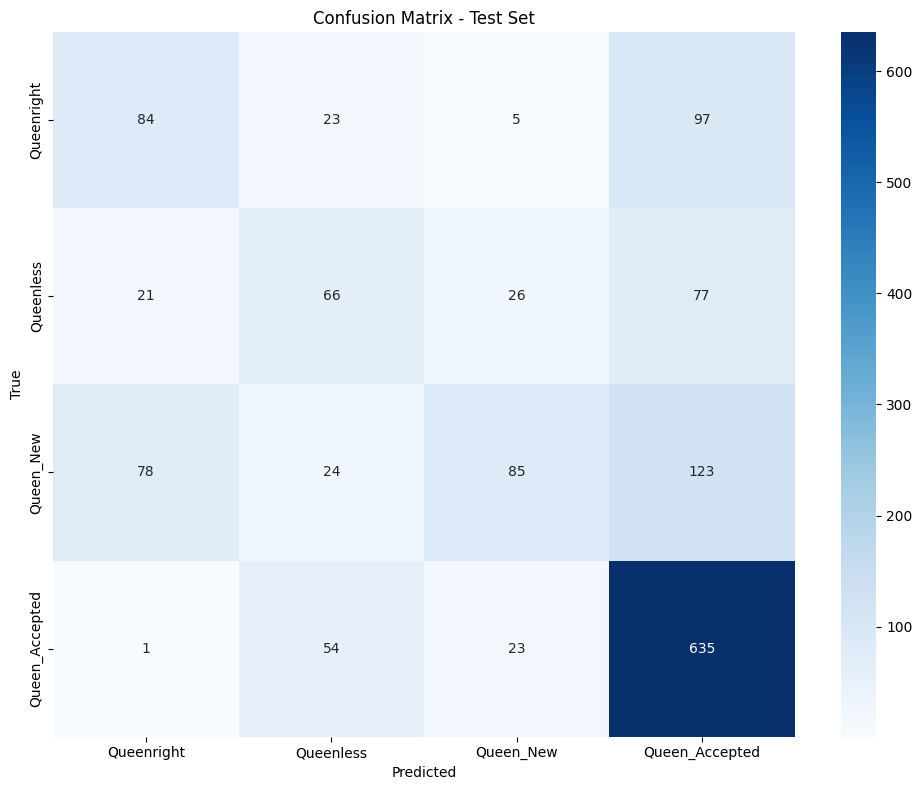

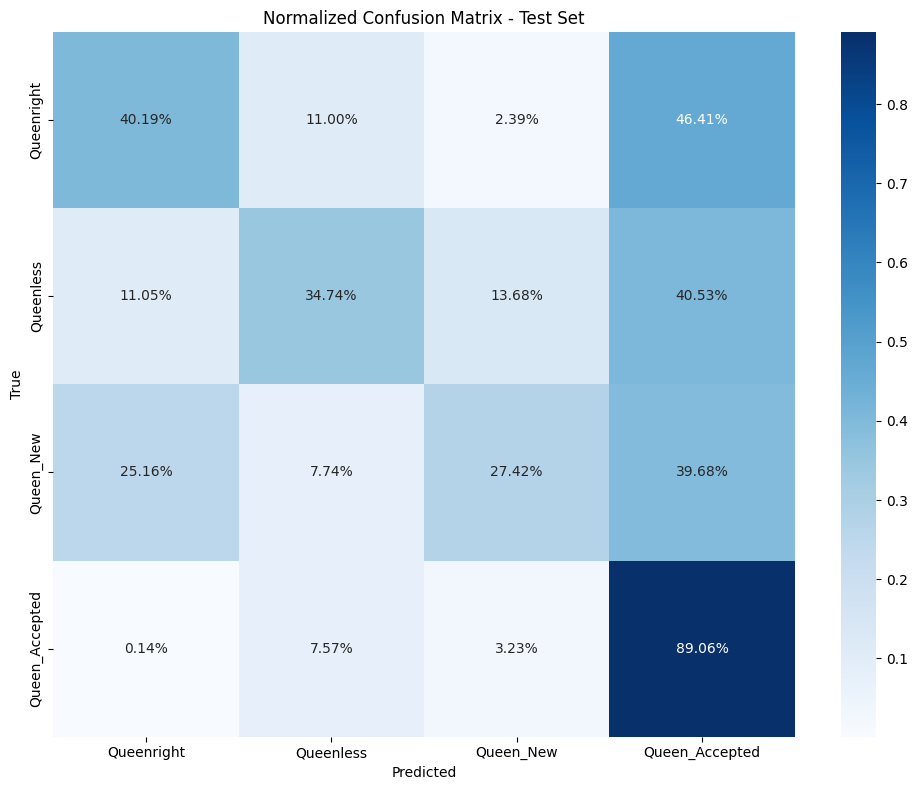

In [14]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Save Model


In [15]:
# Save model
model_path = MODEL_DIR / 'beehive_cnn_classifier.pth'
torch.save({
    'model_state_dict': best_model_state,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'config': config_dict,
    'history': history,
    'test_metrics': {
        'accuracy': test_acc,
        'f1_score': test_f1,
        'loss': test_loss
    }
}, model_path)

print(f"Model saved to {model_path}")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(MODEL_DIR / 'cnn_training_history.csv', index=False)
print(f"Training history saved to {MODEL_DIR / 'cnn_training_history.csv'}")


Model saved to ../outputs/models/beehive_cnn_classifier.pth
Training history saved to ../outputs/models/cnn_training_history.csv


In [16]:
print("=" * 60)
print("CNN CLASSIFIER SUMMARY")
print("=" * 60)
print(f"\nModel Architecture: BeehiveCNN")
print(f"  - 4 Conv blocks (32->64->128->256 filters)")
print(f"  - Global Average Pooling")
print(f"  - Dense layers (256->128->4)")
print(f"  - Total parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\nTraining Configuration:")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Epochs trained: {len(history['train_loss'])}")
print(f"  - Early stopping patience: {PATIENCE}")

print(f"\nFinal Metrics:")
print(f"  - Best Val F1: {best_val_f1:.4f}")
print(f"  - Test Accuracy: {test_acc:.4f}")
print(f"  - Test F1 Score: {test_f1:.4f}")

print(f"\nSaved files:")
print(f"  - {model_path}")
print(f"  - {MODEL_DIR / 'cnn_training_history.csv'}")
print(f"  - {OUTPUT_DIR / 'cnn_training_history.png'}")
print(f"  - {OUTPUT_DIR / 'cnn_confusion_matrix.png'}")


CNN CLASSIFIER SUMMARY

Model Architecture: BeehiveCNN
  - 4 Conv blocks (32->64->128->256 filters)
  - Global Average Pooling
  - Dense layers (256->128->4)
  - Total parameters: 422,212

Training Configuration:
  - Learning rate: 0.001
  - Batch size: 32
  - Epochs trained: 40
  - Early stopping patience: 10

Final Metrics:
  - Best Val F1: 0.6038
  - Test Accuracy: 0.6118
  - Test F1 Score: 0.5819

Saved files:
  - ../outputs/models/beehive_cnn_classifier.pth
  - ../outputs/models/cnn_training_history.csv
  - ../outputs/cnn_training_history.png
  - ../outputs/cnn_confusion_matrix.png
